# TS2

#### Rey Tomás 
#### APS

# Introducción 

Un conversor ADC es un circuito que permite muestrear una señal analógica y convertirla en una digital. En esta simulación virtual, haremos uso de la libreria numpy para generar una señal sinusoidal y la dotaremos de ruido analógico "artificial", ya que sabemos que el ruido analógico tiene una distribución gaussiana por lo que lo fabricaremos con herramientas también de numpy.
Por su parte, la salida digital tiene la característica de tener un ruido causado por la cuantización

$$e_q=s_q-s_r(1)$$

El cual se distribuye idealmente de manera uniforme en el intrervalo [-q/2,q/2] y tiene una potencia de 

$$P_q=q^2/12 (2)$$ 

Donde 

$$q=\frac{2V_r}{2^B}   (3)$$

Luego, la potencia del ruido analógico se relaciona con la del ruido de cuantización según la expresión 

$$P_n=k_n.P_q(4)$$

In [10]:
"""
Created on Wed Sep  2 19:44:59 2026

@author: tomas
"""

'\nCreated on Wed Sep  2 19:44:59 2026\n\n@author: tomas\n'

In [11]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy import stats

Función principal para graficar señal muestreada, potencia e hisograma del ruido

In [20]:
def main_func(B,kn,N,fs,k,Vr):
    
    t=(np.arange(0,N)/fs)
    delta_f=fs/N
    s=np.sqrt(2)*np.sin(k*delta_f*2*np.pi*t)
    
    q=2*Vr/(2**B) #paso de cuantizacion
    Pq=(q**2)/12 #Potencia de ruido 
    Pn=kn*Pq #Potencia analogica que yo predigo para mi señal, basado en la relacion con Pq que depende del paso
    
    desv=np.sqrt(Pn) #La desviacion estandar del ruido es la raiz de mi potencia analogica
    n=np.random.normal(0,desv,size=N)#El ruido sale de una distribución normal
    
    s_r=s+n
    
    #Señal muestreada
    plt.figure()
    plt.plot(t,s,linestyle='--',color='orange',label='s',zorder=5,linewidth=1.5)
    plt.plot(t,s_r,color='green',marker='o',markersize=2,linestyle=':',label='s_r=s+n',alpha=0.7)
    s_q=np.round(s_r/q)*q #Señal digital (salida del ADC) 
    plt.plot(t, s_q, color='blue', label='s_q',alpha=0.6)
    plt.xlabel('tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.title(f'Señal muestrada con {B} bits y kn={kn}')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    frec=np.arange(N//2)*fs/N #solo hasta nyquist
    
    fft_s=np.fft.fft(s)
    fft_s_r=np.fft.fft(s_r)
    fft_s_q=np.fft.fft(s_q)
    
    P_s_db=10*np.log10(np.abs(fft_s[0:N//2]/N)**2) #potencia de señal analógica entrante
    P_sr_db=10*np.log10(np.abs(fft_s_r[0:N//2]/N)**2) #potencia de señal analógica entratne más ruido
    P_sq_db=10*np.log10(np.abs(fft_s_q[0:N//2]/N)**2) #potencia de señal digital saliente (con ruido de cuantización)
    
    plt.figure()
    plt.plot(frec,P_s_db,linestyle='--',color='orange',label='s',zorder=5,linewidth=1.5)
    plt.plot(frec,P_sr_db,color='green',marker='o',markersize=2,linestyle=':',label='s_r=s+n',alpha=0.7)
    plt.plot(frec,P_sq_db,color='blue',label='s_q',alpha=0.6)
    piso_analogico=np.mean(P_sr_db[2:])
    piso_digital=np.mean(P_sq_db[2:])
    plt.axhline(piso_analogico, linestyle='--', color='black', linewidth=1.8, zorder=10,
                label=f'Piso analógico medio: {piso_analogico:.2f} dB')
    plt.axhline(piso_digital, linestyle='--', color='purple', linewidth=1.8, zorder=10,
                label=f'Piso digital medio: {piso_digital:.2f} dB')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [dB]')
    plt.title(f'Potencia espectral para {B} bits y kn={kn}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    #Histograma
    e_q=s_q-s_r
    bins=np.linspace(-q/2,q/2,11)
    
    cant_bines=len(bins)-1
    esperado=N/cant_bines
    
    plt.figure()
    plt.hist(e_q,bins=bins,rwidth=0.95,color='tab:blue',edgecolor='black',label='Ocurrencias')
    plt.hlines(esperado,-q/2,q/2,colors='red',linestyles='--',linewidth=2,label='Uniforme esperada')
    plt.vlines([-q/2,q/2],0,esperado,colors='red',linestyles='--',linewidth=2)
    plt.title('Histograma del error de cuantización')
    plt.xlabel('Error de cuantización [V]')
    plt.ylabel('Ocurrencias')
    plt.xlim(-q/2*1.1,q/2*1.1)
    plt.title(f'Histograma para {B} bits y kn={kn}')
    plt.legend()
    plt.grid(True,alpha=0.4)
    plt.show()
    return()

# a) Para 4 bits y kn=1

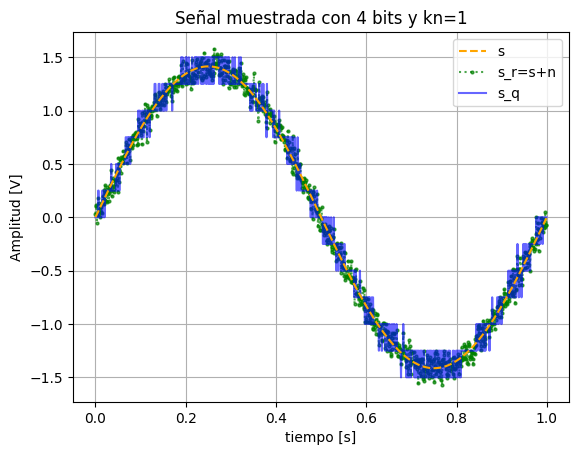

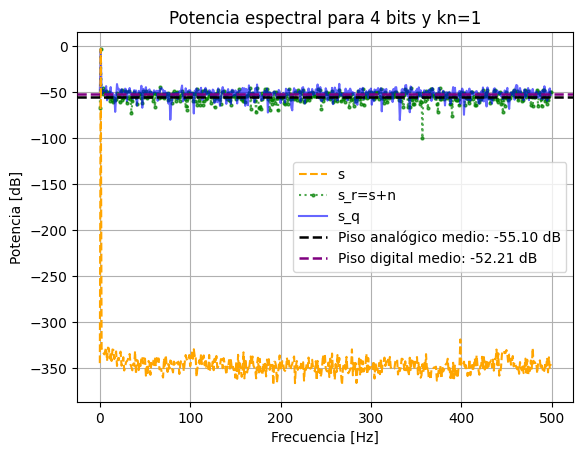

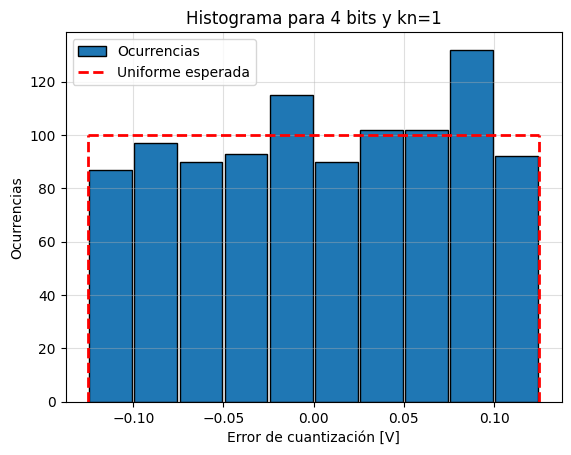

()

In [21]:
#a)
fs=1000 #hz
N=1000 #muestras
k=1
Vr=2 #[V]
B=4
kn=1
main_func(B,kn,N,fs,k,Vr)

El primer gráfico muestra la señal original entrante en amarillo, y luego en verde el efecto del ruido adicionado, que, si bien distorsiona la señal, sigue el patrón de una senoidal. La señal en azul es la digital que sale del ADC luego de la conversión. Se pueden apreciar a simple vista los escalones de la digitalización, esto se debe a que, según la ecuación (2), el paso de cuantización será más grande cuanto más chico sea el número de bits usado en el conversor.

El segundo gráfico permite visualizar la potencia espectral de las tres señales mostradas. Para la señal senoidal original se puede ver toda la potencia concentrada en una frecuencia, ya que es simplemente un seno cuya transformada es una delta que retiene casi toda la potencia y luego de esa frecuencia la potencia de la senoidal es idealmente 0. La señal analógica y digital muestran también una potencia concentrada en el pico, pero luego de ello caen a un piso de ruido mucho mayor, que es la potencia del ruido analógico y digital. Dado que $k_n$=1, la relación entre la distorsión de la señal entrante y la saliente es casi idéntica, cosa que podemos ver gráficamente por lo cercano que están ambas señales, así como numéricamente en los valores en dB del piso de ruido.

El histograma muestra el error máximo y minimo que se puede tener en la cuantización (de -q/2 a q/2) y divide el espacio en 10 bins, luego ordena cada una de las mil conversiones categorizando cuánto fue el error cometido. El resultado fue el esperado, ya que el error de cuantización se distribuyó de manera relativamente uniforme para todas las muestras.

# b) Para 16 bits y kn=1

En esta sección modificaré la cantidad de bits y el $k_n$, por lo que consideraré el caso de 4 bits con $k_n$=1 como  el "caso base"

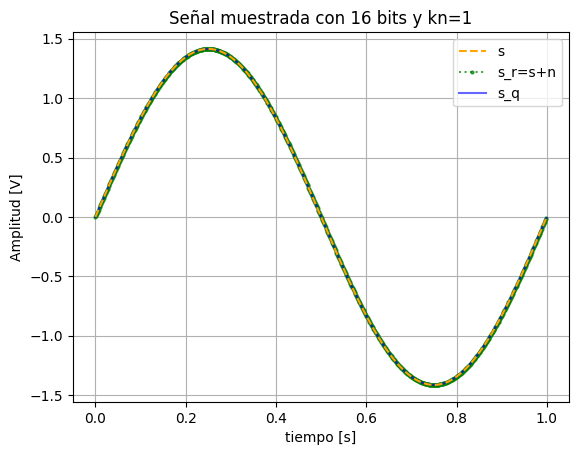

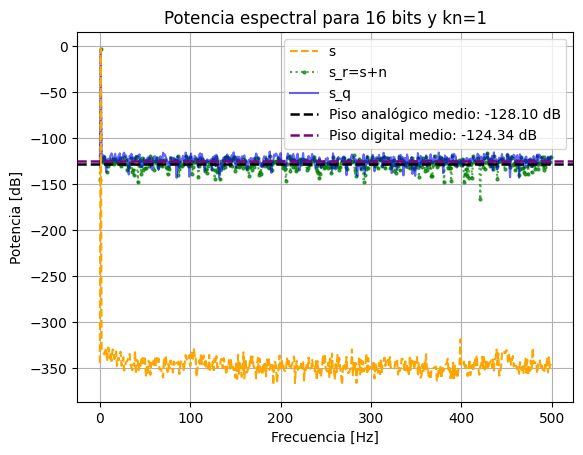

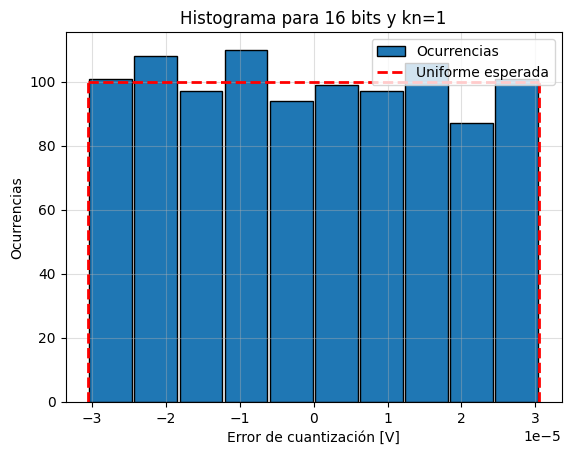

()

In [22]:
B=16
kn=1
main_func(B,kn,N,fs,k,Vr)

El gráfico de señal muestreada muestra un comportamiento distinto al aumentar la cantidad de bits, ya que ahora el ADC tiene una mucha mejor resolución en su paso q por lo que ahora puede seguir la curva de la senoidal (para 4 bits, el paso q era de 0.25 V mientras que con 16 bits pasa a ser de 61$\micro$V). Asímismo, como la relación entre el ruido analógico y digital se mantuvo en 1, aumentar la resolución en bits disminuyó también el ruido analógico, cosa que en el mundo real no tendría que tener sentido. 

Aumentar la cantidad de bits disminuyó el piso de ruido en aproximadamente 70 dB respecto al arreglo con 4 bits, aunque los pisos siguieron siendo similares entre sí debido a que $k_n$ se mantuvo en 1. Estos 70 dB se condicen con la regla de relación señal ruido $\triangle SNR=6.02\triangle B=6.02*12=72.25dB$

El histograma mantuvo un comportamiento uniforme por lo que no se vio afectado por el aumento de bits. Cabe aclarar que a medida que se reduce el q cambian proporcionalmente los límites del eje horizontal del histograma, pero la sumatoria del número de ocurrencias entre todos los bins tiene que siempre ser 1000 (N).

# Para 4 bits y kn=1/10

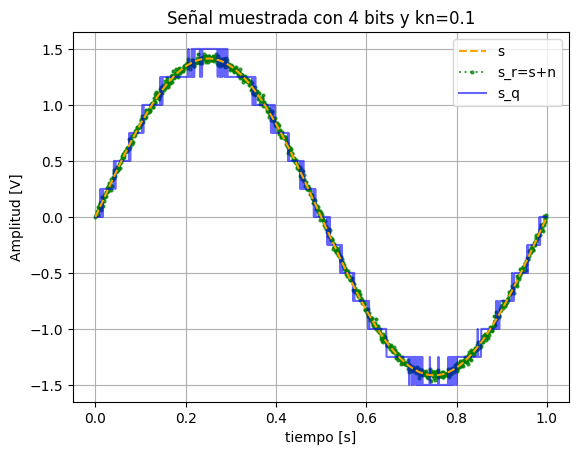

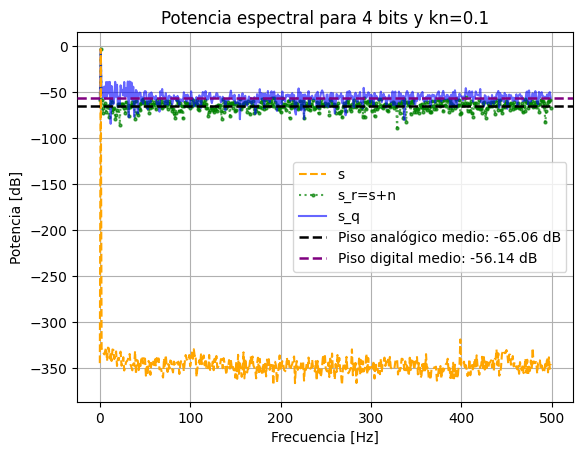

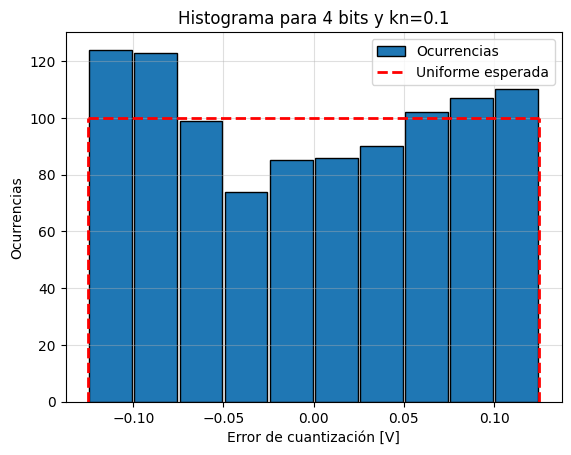

()

In [24]:
B=4
kn=1/10
main_func(B,kn,N,fs,k,Vr) 

Al mantener los bits en 4, pero reducir $k_n$ a 1/10, el ruido de la señal analógica se redujo ya que $k_n$ funcionó como un factor de reducción. Esto se puede apreciar en los primeros dos gráficos, pero en el segundo particularmente se ve de manera más clara como el piso de ruido digital se mantuvo alrededor de unos 56 dB mientras que el analógico bajó en 10 dB, lo que era de esperar ya que ahora la salida del sistema es diez veces la entrada. Cambiar el $k_n$ sí tuvo incidencia en el histograma e hizo que el ruido de cuantización ya no esté uniformemente distribuido, ya que el ruido analógico pequeño frente al paso de cuantización, y se pierde la aleatoriedad que otorga la señal estocástica, por lo que el error de cuantización ahora está más relacionado con la señal senoidal pura, que pasa más tiempo cerca de sus crestas que en sus cruces por cero, lo que hace que no todos los bines de errores cometidos posibles sean equiprobables y rompe la hipótesis de error de cuantización con distribución uniforme.

# Para 4 bits y kn=10

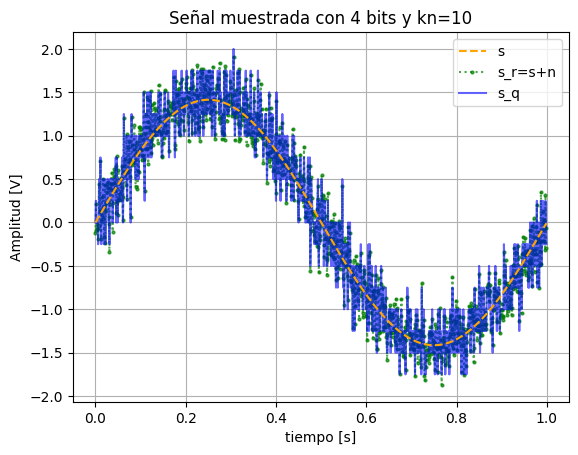

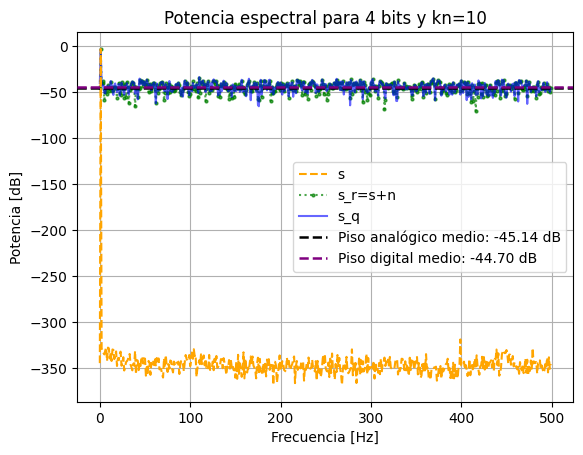

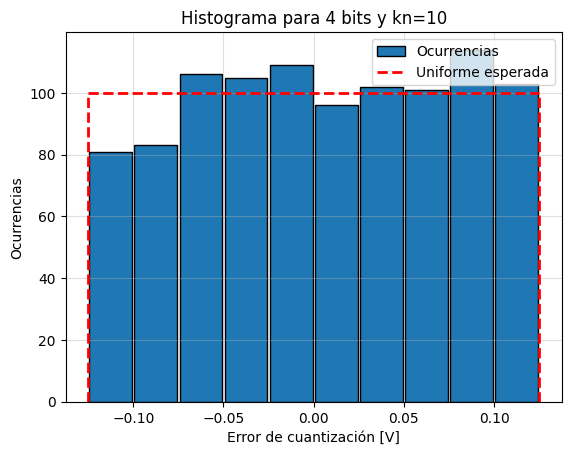

()

In [28]:
B=4
kn=10
main_func(B,kn,N,fs,k,Vr)

Mantener los bits y aumentar el $k_n$ tuvo el efecto contrario al caso anterior, y tanto el ruido digital como el analógico aumentaron en 10 dB respecto al caso base. A diferencia del caso anterior donde lo único que mejoró fue el ruido digital, en este caso, aumentar $k_n$ empeoró ambos ruidos. Ahora, el ruido analógico es muy grande frente al de cuantización, por lo cual el ruido entrante es muy grande y la señal de entrada se vuelve muy aleatoria, haciendo que el error se distribuya de manera uniforme.

# Conclusiones

Aumentar los bits de un conversor reduce el paso q, lo cual tiene un efecto evidente en la disminución del ruido digital y permite transmitir la señal original de manera más fehaciente.

La relación entre la potencia de ruido digital y analógica debe mantenerse idealmente en uno, ya que si esta es mucho menor a 1 se pierde el efecto dither y el error de cuantización se corresponde con qué punto de la señal está tomando en ese momento. Por el contrario, si $k_n$ es mucho mayor a 1, el ruido analógico domina el conversor y eleva el piso de ruido.

Aumentar la relación $k_n$ en 10 veces o reducirla a un décimo causará un aumento o disminución de 10 dB en la potencia del ruido analógico.

Idealmente, un conversor ADC debería tener la mayor cantidad de bits posibles y un $k_n$ lo más cercano posible a 1, garantizando pisos de ruido bajos y un error de cuantización uniformemente distribuído.